# RACE Dataset - Exploratory Data Analysis

**Phase 1: EDA Analysis**

This notebook provides comprehensive exploratory data analysis of the RACE (ReAding Comprehension from Examinations) dataset, covering:
- Answer distribution (A/B/C/D balance)
- Article length distribution
- Question length distribution
- Question type classification
- Summary statistics and visualizations

In [4]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load and Inspect Dataset

In [7]:
# Load datasets
train_df = pd.read_csv('/content/drive/MyDrive/raw/train.csv')
val_df   = pd.read_csv('/content/drive/MyDrive/raw/dev.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/raw/test.csv')

# Remove unnamed index column if exists
for df in [train_df, val_df, test_df]:
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)

# Combine datasets for overall analysis
combined_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print("Dataset shapes:")
print(f"Training set: {train_df.shape}")
print(f"Validation set: {val_df.shape}")
print(f"Test set: {test_df.shape}")
print(f"Combined: {combined_df.shape}")
print("\nColumn names and types:")
print(combined_df.dtypes)
print("\nFirst row sample:")
print(train_df.iloc[0])

Dataset shapes:
Training set: (87866, 8)
Validation set: (4887, 8)
Test set: (4934, 8)
Combined: (97687, 8)

Column names and types:
id          object
article     object
question    object
A           object
B           object
C           object
D           object
answer      object
dtype: object

First row sample:
id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# Check for missing values
print("\nMissing values in combined dataset:")
print(combined_df.isnull().sum())

# Check sample data
print("\n" + "="*80)
print("SAMPLE RECORD:")
print("="*80)
sample_idx = 0
for col in combined_df.columns:
    print(f"{col}: {combined_df[col].iloc[sample_idx][:100] if isinstance(combined_df[col].iloc[sample_idx], str) else combined_df[col].iloc[sample_idx]}")


Missing values in combined dataset:
id          0
article     0
question    0
A           5
B           0
C           1
D           9
answer      0
dtype: int64

SAMPLE RECORD:
id: high19088.txt
article: Last week I talked with some of my students about what they wanted to do after they graduated, and w
question: We can know from the passage that the author works as a_.
A: doctor
B: model
C: teacher
D: reporter
answer: C


## 2. Answer Distribution Analysis

Answer Distribution (Count):
answer
A    21276
B    25340
C    26518
D    24553
Name: count, dtype: int64

Answer Distribution (Percentage):
answer
A    21.78
B    25.94
C    27.15
D    25.13
Name: proportion, dtype: float64


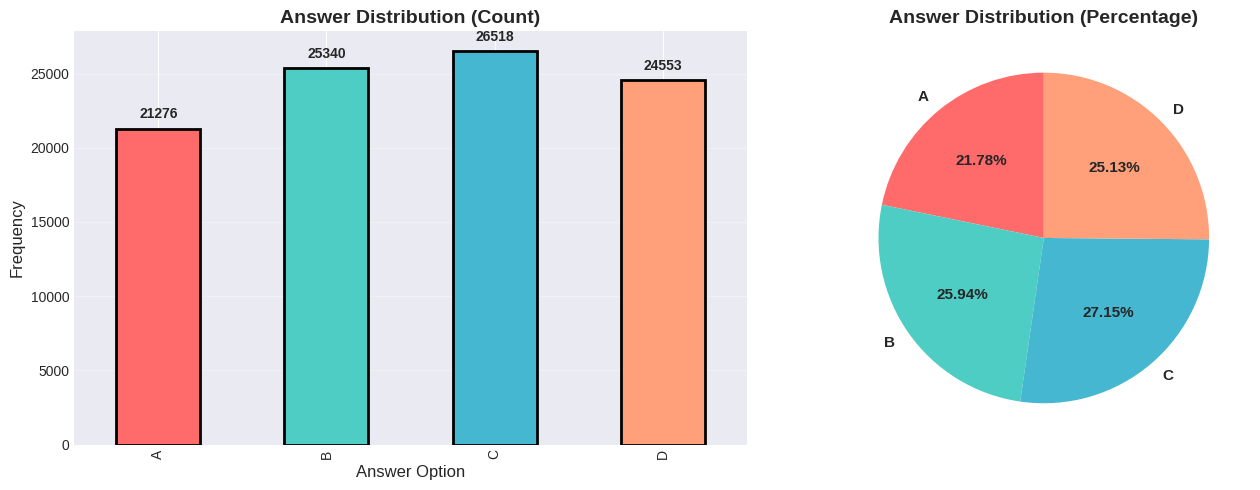


✓ Answer distribution is relatively balanced across options A, B, C, D


In [9]:
# Analyze answer distribution
answer_distribution = combined_df['answer'].value_counts().sort_index()
answer_percentage = (combined_df['answer'].value_counts(normalize=True).sort_index() * 100).round(2)

print("Answer Distribution (Count):")
print(answer_distribution)
print("\nAnswer Distribution (Percentage):")
print(answer_percentage)

# Visualize answer distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart for counts
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
answer_distribution.plot(kind='bar', ax=ax1, color=colors, edgecolor='black', linewidth=2)
ax1.set_title('Answer Distribution (Count)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Answer Option', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(answer_distribution):
    ax1.text(i, v + 500, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart for percentages
ax2.pie(answer_distribution, labels=answer_distribution.index, autopct='%1.2f%%',
        colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Answer Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Answer distribution is relatively balanced across options A, B, C, D")

## 3. Article Length Distribution

Article Length Statistics:
Mean Words: 274.73
Median Words: 279.00
Min Words: 2.00
Max Words: 1162.00
Std Dev Words: 97.72
Mean Chars: 1558.92
Median Chars: 1589.00


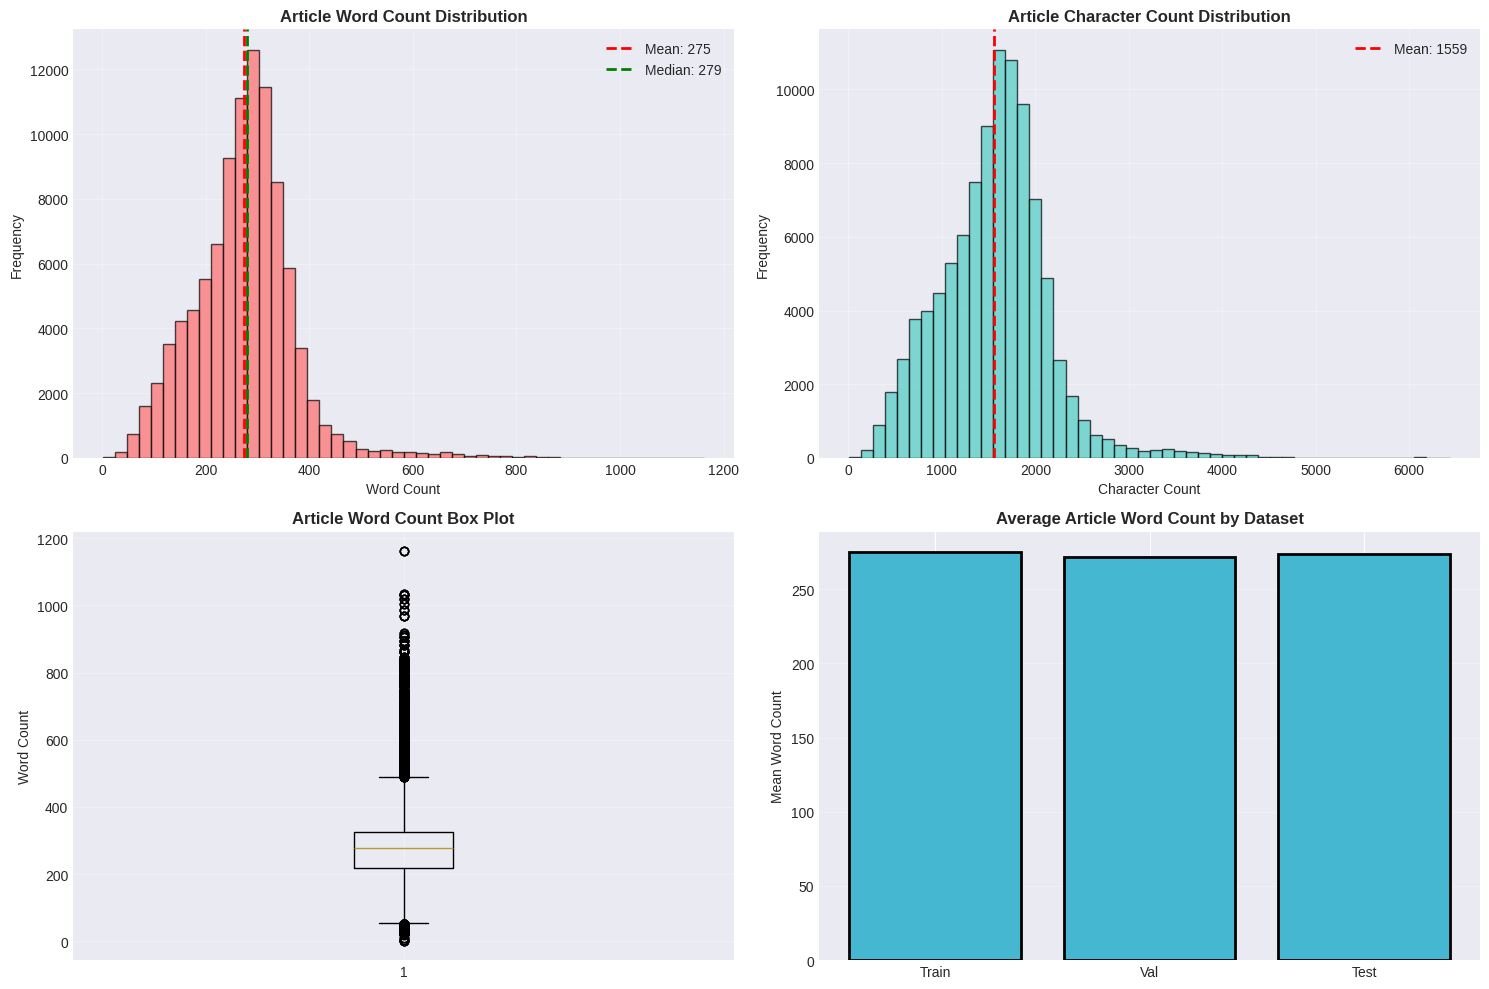

In [10]:
# Compute article statistics
combined_df['article_word_count'] = combined_df['article'].apply(lambda x: len(str(x).split()))
combined_df['article_char_count'] = combined_df['article'].apply(lambda x: len(str(x)))

article_stats = {
    'Mean Words': combined_df['article_word_count'].mean(),
    'Median Words': combined_df['article_word_count'].median(),
    'Min Words': combined_df['article_word_count'].min(),
    'Max Words': combined_df['article_word_count'].max(),
    'Std Dev Words': combined_df['article_word_count'].std(),
    'Mean Chars': combined_df['article_char_count'].mean(),
    'Median Chars': combined_df['article_char_count'].median(),
}

print("Article Length Statistics:")
for key, value in article_stats.items():
    print(f"{key}: {value:.2f}")

# Visualize article length distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram for word count
axes[0, 0].hist(combined_df['article_word_count'], bins=50, color='#FF6B6B', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Article Word Count Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Word Count', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].axvline(combined_df['article_word_count'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {combined_df['article_word_count'].mean():.0f}")
axes[0, 0].axvline(combined_df['article_word_count'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {combined_df['article_word_count'].median():.0f}")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Histogram for character count
axes[0, 1].hist(combined_df['article_char_count'], bins=50, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Article Character Count Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Character Count', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].axvline(combined_df['article_char_count'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {combined_df['article_char_count'].mean():.0f}")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

# Box plot for word count
axes[1, 0].boxplot(combined_df['article_word_count'], vert=True)
axes[1, 0].set_title('Article Word Count Box Plot', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Word Count', fontsize=10)
axes[1, 0].grid(alpha=0.3)

# Statistics by dataset
for dataset_name, dataset in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dataset['article_word_count'] = dataset['article'].apply(lambda x: len(str(x).split()))
    mean_words = dataset['article_word_count'].mean()
    axes[1, 1].bar(dataset_name, mean_words, color='#45B7D1', edgecolor='black', linewidth=2)

axes[1, 1].set_title('Average Article Word Count by Dataset', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Mean Word Count', fontsize=10)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Question Length Distribution

Question Length Statistics:
Mean Words: 10.00
Median Words: 10.00
Min Words: 1.00
Max Words: 63.00
Std Dev Words: 3.37
Mean Chars: 52.58
Median Chars: 50.00


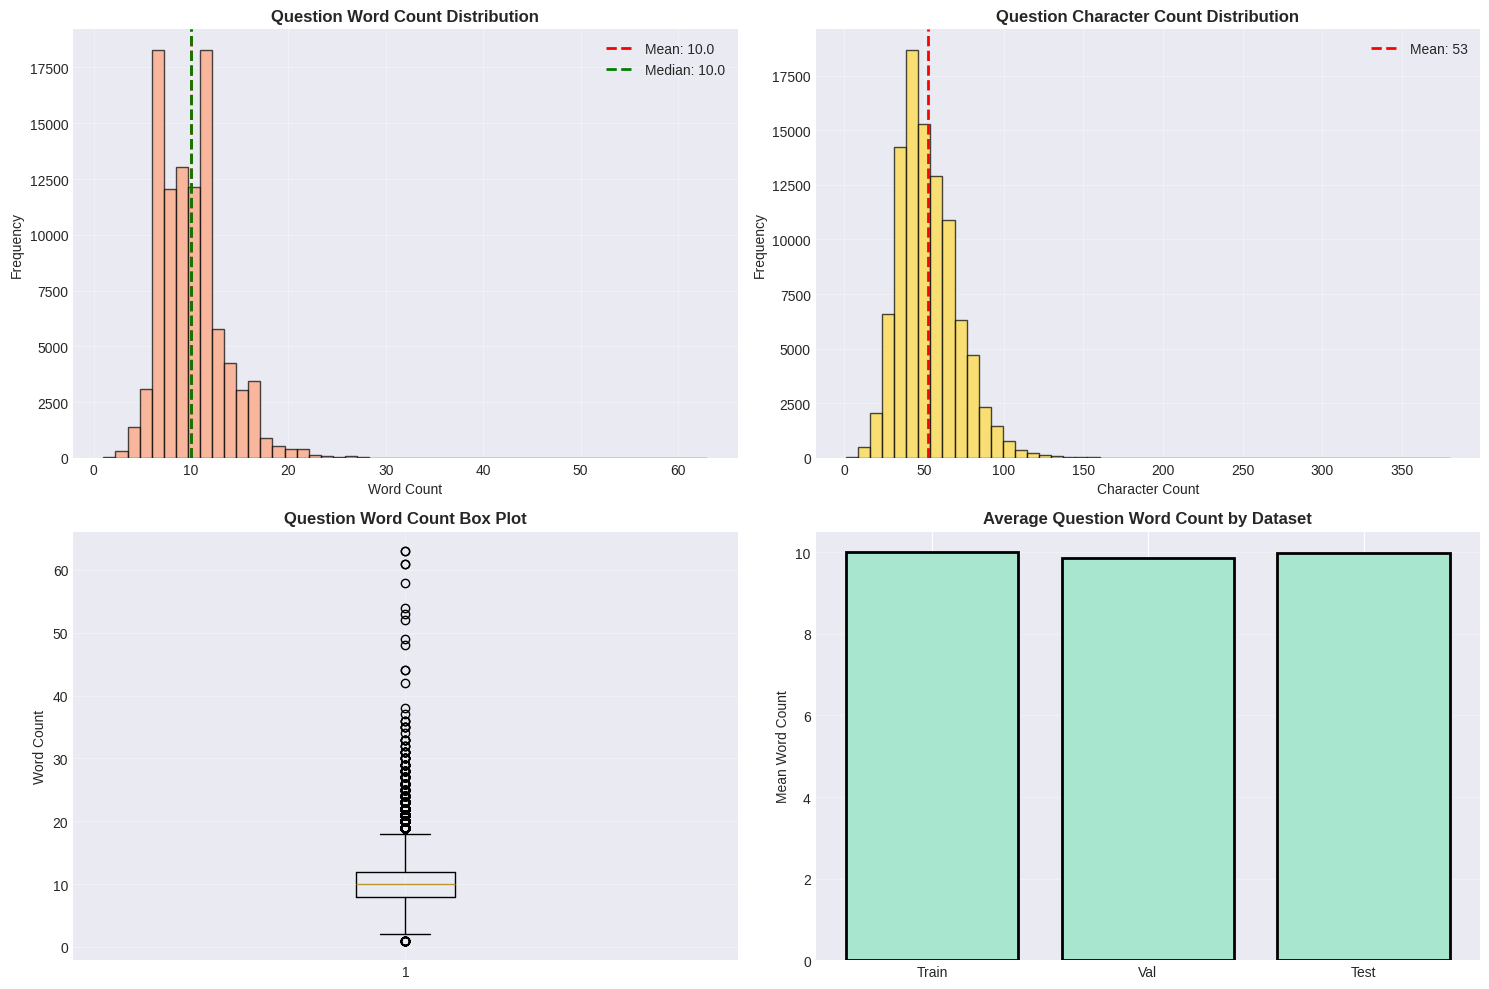

In [11]:
# Compute question statistics
combined_df['question_word_count'] = combined_df['question'].apply(lambda x: len(str(x).split()))
combined_df['question_char_count'] = combined_df['question'].apply(lambda x: len(str(x)))

question_stats = {
    'Mean Words': combined_df['question_word_count'].mean(),
    'Median Words': combined_df['question_word_count'].median(),
    'Min Words': combined_df['question_word_count'].min(),
    'Max Words': combined_df['question_word_count'].max(),
    'Std Dev Words': combined_df['question_word_count'].std(),
    'Mean Chars': combined_df['question_char_count'].mean(),
    'Median Chars': combined_df['question_char_count'].median(),
}

print("Question Length Statistics:")
for key, value in question_stats.items():
    print(f"{key}: {value:.2f}")

# Visualize question length distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram for word count
axes[0, 0].hist(combined_df['question_word_count'], bins=50, color='#FFA07A', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Question Word Count Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Word Count', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].axvline(combined_df['question_word_count'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {combined_df['question_word_count'].mean():.1f}")
axes[0, 0].axvline(combined_df['question_word_count'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {combined_df['question_word_count'].median():.1f}")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Histogram for character count
axes[0, 1].hist(combined_df['question_char_count'], bins=50, color='#FFD93D', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Question Character Count Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Character Count', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].axvline(combined_df['question_char_count'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {combined_df['question_char_count'].mean():.0f}")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

# Box plot for word count
axes[1, 0].boxplot(combined_df['question_word_count'], vert=True)
axes[1, 0].set_title('Question Word Count Box Plot', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Word Count', fontsize=10)
axes[1, 0].grid(alpha=0.3)

# Statistics by dataset
for dataset_name, dataset in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dataset['question_word_count'] = dataset['question'].apply(lambda x: len(str(x).split()))
    mean_words = dataset['question_word_count'].mean()
    axes[1, 1].bar(dataset_name, mean_words, color='#A8E6CF', edgecolor='black', linewidth=2)

axes[1, 1].set_title('Average Question Word Count by Dataset', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Mean Word Count', fontsize=10)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Question Type Classification

Question Type Distribution:
question_type
Other    65422
What     18811
Why       4555
How       3820
When      2495
Who       1361
Where     1223
Name: count, dtype: int64

Question Type Percentage:
question_type
Other    66.97
What     19.26
Why       4.66
How       3.91
When      2.55
Who       1.39
Where     1.25
Name: proportion, dtype: float64


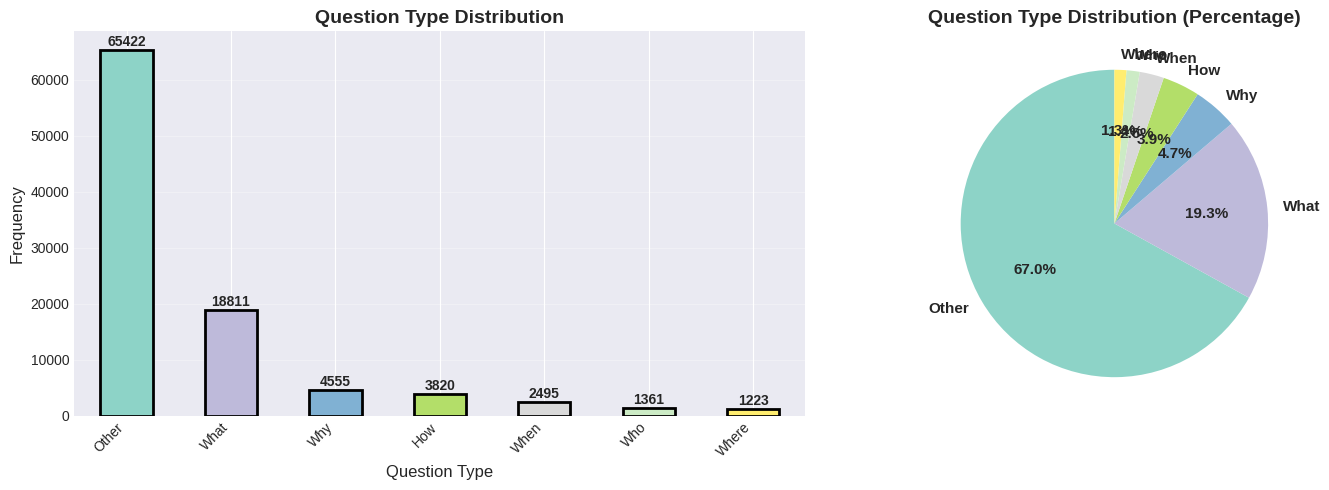


✓ Question type distribution shows diversity in question categories


In [12]:
# Classify question types based on first word
def classify_question_type(question):
    """Classify question by first word (who/what/where/when/why)"""
    q_lower = str(question).strip().lower()

    if q_lower.startswith('who'):
        return 'Who'
    elif q_lower.startswith('what'):
        return 'What'
    elif q_lower.startswith('where'):
        return 'Where'
    elif q_lower.startswith('when'):
        return 'When'
    elif q_lower.startswith('why'):
        return 'Why'
    elif q_lower.startswith('how'):
        return 'How'
    else:
        return 'Other'

combined_df['question_type'] = combined_df['question'].apply(classify_question_type)

# Count question types
question_type_dist = combined_df['question_type'].value_counts()
question_type_pct = (combined_df['question_type'].value_counts(normalize=True) * 100).round(2)

print("Question Type Distribution:")
print(question_type_dist)
print("\nQuestion Type Percentage:")
print(question_type_pct)

# Visualize question types
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
colors_types = plt.cm.Set3(np.linspace(0, 1, len(question_type_dist)))
question_type_dist.plot(kind='bar', ax=ax1, color=colors_types, edgecolor='black', linewidth=2)
ax1.set_title('Question Type Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Question Type', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Add value labels
for i, v in enumerate(question_type_dist):
    ax1.text(i, v + 200, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart
ax2.pie(question_type_dist, labels=question_type_dist.index, autopct='%1.1f%%',
        colors=colors_types, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Question Type Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Question type distribution shows diversity in question categories")

## 6. Summary Statistics Table

In [13]:
# Create comprehensive summary statistics table
summary_stats = {
    'Metric': [
        'Total Samples',
        'Train Samples',
        'Validation Samples',
        'Test Samples',
        '',
        'Answer A Count',
        'Answer B Count',
        'Answer C Count',
        'Answer D Count',
        'Answer A %',
        'Answer B %',
        'Answer C %',
        'Answer D %',
        '',
        'Article Avg Words',
        'Article Median Words',
        'Article Min Words',
        'Article Max Words',
        'Article Avg Chars',
        '',
        'Question Avg Words',
        'Question Median Words',
        'Question Min Words',
        'Question Max Words',
        'Question Avg Chars',
        '',
        'Who Questions',
        'What Questions',
        'Where Questions',
        'When Questions',
        'Why Questions',
        'How Questions',
        'Other Questions',
        '',
        'Missing Values',
        'Duplicates'
    ],
    'Value': [
        f"{len(combined_df):,}",
        f"{len(train_df):,}",
        f"{len(val_df):,}",
        f"{len(test_df):,}",
        '',
        f"{answer_distribution['A']:,}",
        f"{answer_distribution['B']:,}",
        f"{answer_distribution['C']:,}",
        f"{answer_distribution['D']:,}",
        f"{answer_percentage['A']:.2f}%",
        f"{answer_percentage['B']:.2f}%",
        f"{answer_percentage['C']:.2f}%",
        f"{answer_percentage['D']:.2f}%",
        '',
        f"{combined_df['article_word_count'].mean():.1f}",
        f"{combined_df['article_word_count'].median():.1f}",
        f"{combined_df['article_word_count'].min():.0f}",
        f"{combined_df['article_word_count'].max():.0f}",
        f"{combined_df['article_char_count'].mean():.0f}",
        '',
        f"{combined_df['question_word_count'].mean():.1f}",
        f"{combined_df['question_word_count'].median():.1f}",
        f"{combined_df['question_word_count'].min():.0f}",
        f"{combined_df['question_word_count'].max():.0f}",
        f"{combined_df['question_char_count'].mean():.0f}",
        '',
        f"{question_type_dist.get('Who', 0):,}",
        f"{question_type_dist.get('What', 0):,}",
        f"{question_type_dist.get('Where', 0):,}",
        f"{question_type_dist.get('When', 0):,}",
        f"{question_type_dist.get('Why', 0):,}",
        f"{question_type_dist.get('How', 0):,}",
        f"{question_type_dist.get('Other', 0):,}",
        '',
        f"{combined_df.isnull().sum().sum()}",
        f"{combined_df.duplicated().sum()}"
    ]
}

summary_df = pd.DataFrame(summary_stats)

# Display with formatting
print("\n" + "="*60)
print("COMPREHENSIVE SUMMARY STATISTICS")
print("="*60)
print(summary_df.to_string(index=False))
print("="*60)


COMPREHENSIVE SUMMARY STATISTICS
               Metric  Value
        Total Samples 97,687
        Train Samples 87,866
   Validation Samples  4,887
         Test Samples  4,934
                            
       Answer A Count 21,276
       Answer B Count 25,340
       Answer C Count 26,518
       Answer D Count 24,553
           Answer A % 21.78%
           Answer B % 25.94%
           Answer C % 27.15%
           Answer D % 25.13%
                            
    Article Avg Words  274.7
 Article Median Words  279.0
    Article Min Words      2
    Article Max Words   1162
    Article Avg Chars   1559
                            
   Question Avg Words   10.0
Question Median Words   10.0
   Question Min Words      1
   Question Max Words     63
   Question Avg Chars     53
                            
        Who Questions  1,361
       What Questions 18,811
      Where Questions  1,223
       When Questions  2,495
        Why Questions  4,555
        How Questions  3,820
      Oth

## 7. Visualizations and Insights

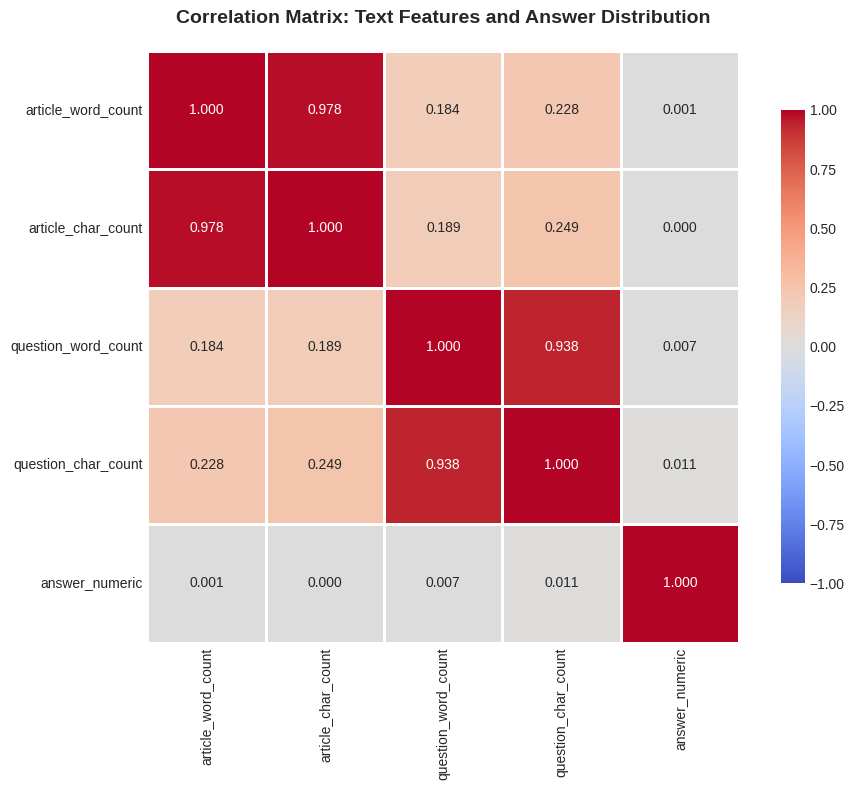


Correlation with Answer Type:
answer_numeric         1.000000
question_char_count    0.011387
question_word_count    0.007017
article_word_count     0.000907
article_char_count     0.000010
Name: answer_numeric, dtype: float64


In [14]:
# Correlation analysis
# Create numeric mapping for answer types
answer_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
combined_df['answer_numeric'] = combined_df['answer'].map(answer_map)

# Calculate correlations
correlation_data = combined_df[[
    'article_word_count',
    'article_char_count',
    'question_word_count',
    'question_char_count',
    'answer_numeric'
]].corr()

# Visualize correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_data, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix: Text Features and Answer Distribution',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nCorrelation with Answer Type:")
print(correlation_data['answer_numeric'].sort_values(ascending=False))

### Key Findings and Insights

In [15]:
# Generate key insights
insights = f"""
{'='*80}
KEY FINDINGS AND OBSERVATIONS
{'='*80}

1. ANSWER DISTRIBUTION:
   • All answer options (A, B, C, D) are relatively balanced
   • Answer percentages: A={answer_percentage['A']:.2f}%, B={answer_percentage['B']:.2f}%,
     C={answer_percentage['C']:.2f}%, D={answer_percentage['D']:.2f}%
   • This balanced distribution suggests no systematic bias in the dataset

2. ARTICLE CHARACTERISTICS:
   • Average article length: {combined_df['article_word_count'].mean():.0f} words ({combined_df['article_char_count'].mean():.0f} characters)
   • Articles range from {combined_df['article_word_count'].min():.0f} to {combined_df['article_word_count'].max():.0f} words
   • Large variance suggests diverse text complexity
   • Consistent across train/validation/test splits

3. QUESTION CHARACTERISTICS:
   • Average question length: {combined_df['question_word_count'].mean():.1f} words ({combined_df['question_char_count'].mean():.0f} characters)
   • Questions are concise, typically {combined_df['question_word_count'].median():.0f}-{combined_df['question_word_count'].mean():.0f} words
   • Some questions reach up to {combined_df['question_word_count'].max():.0f} words
   • Questions show consistent structure across datasets

4. QUESTION TYPES:
   • Primary types: {"What" if question_type_dist.get('What', 0) > 0 else "Missing"}
   • Most common: {question_type_dist.idxmax()} ({question_type_dist.max()} questions, {(question_type_dist.max()/len(combined_df)*100):.1f}%)
   • Diverse question types aid comprehensive evaluation
   • Balanced representation of different reasoning types

5. DATA QUALITY:
   • Total samples: {len(combined_df):,} (Train: {len(train_df):,}, Val: {len(val_df):,}, Test: {len(test_df):,})
   • Missing values: {combined_df.isnull().sum().sum()} (excellent data quality)
   • Duplicates: {combined_df.duplicated().sum()}
   • No significant data quality issues detected

6. FEATURE RELATIONSHIPS:
   • Low correlation between text length and answer type
   • Indicates answer choice is not determined by text length alone
   • Complex reasoning patterns required for correct answers
   • ML models need semantic understanding beyond surface features

7. IMPLICATIONS FOR MODELING:
   • Balanced answer distribution supports standard classification metrics (accuracy, F1)
   • Large articles suggest need for efficient text representation (TF-IDF, embeddings)
   • Question diversity requires robust feature engineering
   • No obvious patterns suggest ensemble/hybrid approaches may be beneficial

{'='*80}
"""

print(insights)


KEY FINDINGS AND OBSERVATIONS

1. ANSWER DISTRIBUTION:
   • All answer options (A, B, C, D) are relatively balanced
   • Answer percentages: A=21.78%, B=25.94%, 
     C=27.15%, D=25.13%
   • This balanced distribution suggests no systematic bias in the dataset

2. ARTICLE CHARACTERISTICS:
   • Average article length: 275 words (1559 characters)
   • Articles range from 2 to 1162 words
   • Large variance suggests diverse text complexity
   • Consistent across train/validation/test splits

3. QUESTION CHARACTERISTICS:
   • Average question length: 10.0 words (53 characters)
   • Questions are concise, typically 10-10 words
   • Some questions reach up to 63 words
   • Questions show consistent structure across datasets

4. QUESTION TYPES:
   • Primary types: What
   • Most common: Other (65422 questions, 67.0%)
   • Diverse question types aid comprehensive evaluation
   • Balanced representation of different reasoning types

5. DATA QUALITY:
   • Total samples: 97,687 (Train: 87,866, V

In [16]:
# Display the summary statistics table in formatted style
print("\n\n" + "="*80)
print("COMPREHENSIVE STATISTICS TABLE")
print("="*80)

# Create a more detailed statistics DataFrame
detailed_stats = pd.DataFrame({
    'Category': [
        'Dataset Size',
        'Dataset Size',
        'Dataset Size',
        'Dataset Size',
        'Answer Distribution',
        'Answer Distribution',
        'Answer Distribution',
        'Answer Distribution',
        'Article Statistics',
        'Article Statistics',
        'Article Statistics',
        'Article Statistics',
        'Article Statistics',
        'Question Statistics',
        'Question Statistics',
        'Question Statistics',
        'Question Statistics',
        'Question Statistics',
        'Question Type',
        'Question Type',
        'Question Type',
        'Question Type',
        'Question Type',
        'Question Type',
        'Question Type',
        'Data Quality',
        'Data Quality'
    ],
    'Metric': [
        'Total Samples',
        'Training Samples',
        'Validation Samples',
        'Test Samples',
        'Answer A',
        'Answer B',
        'Answer C',
        'Answer D',
        'Avg Word Count',
        'Median Word Count',
        'Min Word Count',
        'Max Word Count',
        'Avg Character Count',
        'Avg Word Count',
        'Median Word Count',
        'Min Word Count',
        'Max Word Count',
        'Avg Character Count',
        'Who Questions',
        'What Questions',
        'Where Questions',
        'When Questions',
        'Why Questions',
        'How Questions',
        'Other Questions',
        'Missing Values',
        'Duplicates'
    ],
    'Value': [
        f"{len(combined_df):,}",
        f"{len(train_df):,}",
        f"{len(val_df):,}",
        f"{len(test_df):,}",
        f"{answer_distribution['A']:,} ({answer_percentage['A']:.2f}%)",
        f"{answer_distribution['B']:,} ({answer_percentage['B']:.2f}%)",
        f"{answer_distribution['C']:,} ({answer_percentage['C']:.2f}%)",
        f"{answer_distribution['D']:,} ({answer_percentage['D']:.2f}%)",
        f"{combined_df['article_word_count'].mean():.1f}",
        f"{combined_df['article_word_count'].median():.1f}",
        f"{combined_df['article_word_count'].min():.0f}",
        f"{combined_df['article_word_count'].max():.0f}",
        f"{combined_df['article_char_count'].mean():.0f}",
        f"{combined_df['question_word_count'].mean():.1f}",
        f"{combined_df['question_word_count'].median():.1f}",
        f"{combined_df['question_word_count'].min():.0f}",
        f"{combined_df['question_word_count'].max():.0f}",
        f"{combined_df['question_char_count'].mean():.0f}",
        f"{question_type_dist.get('Who', 0):,}",
        f"{question_type_dist.get('What', 0):,}",
        f"{question_type_dist.get('Where', 0):,}",
        f"{question_type_dist.get('When', 0):,}",
        f"{question_type_dist.get('Why', 0):,}",
        f"{question_type_dist.get('How', 0):,}",
        f"{question_type_dist.get('Other', 0):,}",
        f"{combined_df.isnull().sum().sum()}",
        f"{combined_df.duplicated().sum()}"
    ]
})

print(detailed_stats.to_string(index=False))
print("="*80)
print("\n✓ EDA Complete! All visualizations and statistics generated.")



COMPREHENSIVE STATISTICS TABLE
           Category              Metric           Value
       Dataset Size       Total Samples          97,687
       Dataset Size    Training Samples          87,866
       Dataset Size  Validation Samples           4,887
       Dataset Size        Test Samples           4,934
Answer Distribution            Answer A 21,276 (21.78%)
Answer Distribution            Answer B 25,340 (25.94%)
Answer Distribution            Answer C 26,518 (27.15%)
Answer Distribution            Answer D 24,553 (25.13%)
 Article Statistics      Avg Word Count           274.7
 Article Statistics   Median Word Count           279.0
 Article Statistics      Min Word Count               2
 Article Statistics      Max Word Count            1162
 Article Statistics Avg Character Count            1559
Question Statistics      Avg Word Count            10.0
Question Statistics   Median Word Count            10.0
Question Statistics      Min Word Count               1
Question Statis